---
date: "2026-07-13"
date-modified: last-modified
format:
  html:
    toc: true
---
<!-- CELL BREAK -->

# The $\sigma$-Algebra of Measurable Sets

We have previously established that the collection of [measurable sets](measurable-sets.ipynb) forms an algebra: they are closed under complements and finite unions. To build a robust framework for integration, we need to extend these finite operations to countable ones. In this note, we will prove that the measurable sets actually form a [$\sigma$-algebra](sigma-algebra.ipynb), meaning they are closed under countable unions.

## 1. Sets of Measure Zero are Measurable

Before tackling countable unions, we prove a highly useful property regarding sets that have an [outer measure](lebesgue-outer-measure.ipynb) of zero.

**Proposition:** If $Z \subseteq \mathbb{R}$ is a set such that $m^*(Z) = 0$, then $Z$ is measurable.

::: {.callout-tip collapse="false"}
## Proof of Proposition

Let $A \subseteq \mathbb{R}$ be an arbitrary test set. We must show that $m^*(A) \ge m^*(A \cap Z) + m^*(A \cap Z^c)$.

**Step 1:** Bound the intersection with $Z$.
Because $A \cap Z \subseteq Z$, the monotonicity of the outer measure implies:
$$m^*(A \cap Z) \le m^*(Z) = 0$$
Since outer measure is non-negative, this forces $m^*(A \cap Z) = 0$.

**Step 2:** Bound the intersection with $Z^c$.
Similarly, because $A \cap Z^c \subseteq A$, monotonicity implies:
$$m^*(A \cap Z^c) \le m^*(A)$$

**Step 3:** Combine the bounds.
Adding the results of Step 1 and Step 2 yields:
$$\begin{aligned} m^*(A \cap Z) + m^*(A \cap Z^c) &= 0 + m^*(A \cap Z^c) \\ &\le m^*(A) \end{aligned}$$
Thus, Carathéodory's criterion is satisfied, and $Z$ is measurable. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Completeness of the Lebesgue Measure
This proposition ensures that the Lebesgue measure is a [complete measure](measure-properties-and-completion.ipynb#complete-measure-spaces). If a set is negligible (has zero "volume"), it cannot contain any non-measurable pathologies. Any subset of a measure zero set also has measure zero, and is therefore automatically measurable.
:::

<!-- CELL BREAK -->

## 2. Finite Additivity on Disjoint Sets

When measurable sets are disjoint, they partition any test set $A$ into pieces whose outer measures sum perfectly.

**Lemma (Intersection Additivity):** Let $E_1, E_2, \dots, E_n$ be a finite sequence of pairwise disjoint measurable sets. For any test set $A \subseteq \mathbb{R}$, we have:
$$m^*\left(A \cap \bigcup_{i=1}^n E_i \right) = \sum_{i=1}^n m^*(A \cap E_i)$$


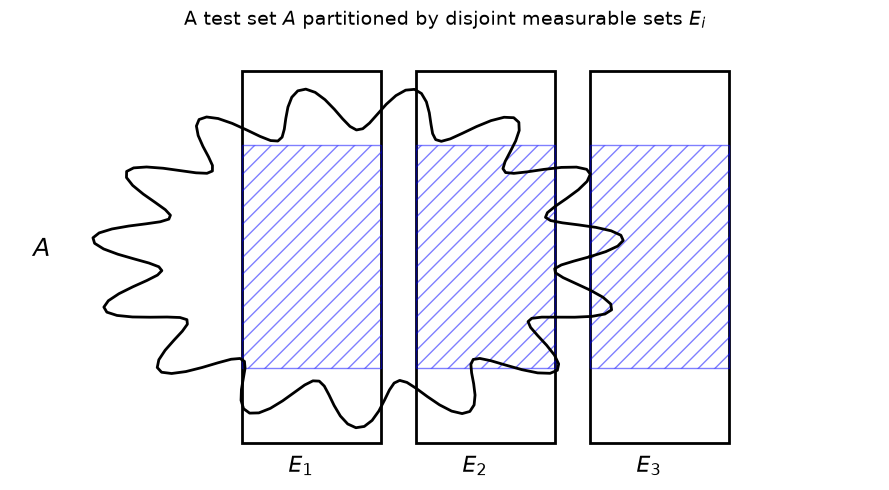

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path

fig, ax = plt.subplots(figsize=(9, 5))

# Draw the test set A as a wavy blob
theta = np.linspace(0, 2*np.pi, 200)
r = 2 + 0.3 * np.sin(15 * theta)
x_A = 4 + r * np.cos(theta)
y_A = 3 + r * np.sin(theta)
ax.plot(x_A, y_A, color='black', lw=2)
ax.text(1.2, 3, '$A$', fontsize=18, fontweight='bold')

# Create disjoint sets E1, E2, E3
rects = [
    Rectangle((3, 0.5), 1.2, 5, facecolor='none', edgecolor='black', lw=2),
    Rectangle((4.5, 0.5), 1.2, 5, facecolor='none', edgecolor='black', lw=2),
    Rectangle((6, 0.5), 1.2, 5, facecolor='none', edgecolor='black', lw=2)
]
labels = ['$E_1$', '$E_2$', '$E_3$']

# Draw rectangles and hatch their intersections with A conceptually
for i, rect in enumerate(rects):
    ax.add_patch(rect)
    # Highlight the intersection zone conceptually
    intersection = Rectangle((rect.get_x(), 1.5), rect.get_width(), 3, 
                             facecolor='none', hatch='//', edgecolor='blue', alpha=0.5)
    ax.add_patch(intersection)
    ax.text(rect.get_x() + 0.4, 0.1, labels[i], fontsize=16)

ax.set_xlim(1, 8.5)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title("A test set $A$ partitioned by disjoint measurable sets $E_i$", fontsize=14)

plt.tight_layout()
plt.show()

::: {.callout-tip collapse="false"}

## Proof of Lemma

We proceed by mathematical induction on $n$.

**Base Case ($n=1$):**
The statement $m^*(A \cap E_1) = m^*(A \cap E_1)$ is trivially true.

**Inductive Step:**
Assume the statement holds for $n-1$. Let $S_{n-1} = \bigcup_{i=1}^{n-1} E_i$ and $S_n = \bigcup_{i=1}^n E_i$. We evaluate the outer measure of $A \cap S_n$ by using $E_n$ as the "knife".

Since $E_n$ is measurable, we apply Carathéodory's criterion using $A \cap S_n$ as our test set:

$$m^*(A \cap S_n) = m^*((A \cap S_n) \cap E_n) + m^*((A \cap S_n) \cap E_n^c)$$

Because the sets $E_i$ are pairwise disjoint, $S_n \cap E_n = E_n$. Also, the portion of $S_n$ outside of $E_n$ is exactly the rest of the union, so $S_n \cap E_n^c = S_{n-1}$. Substituting these in:

$$m^*(A \cap S_n) = m^*(A \cap E_n) + m^*(A \cap S_{n-1})$$

By our inductive hypothesis, $m^*(A \cap S_{n-1}) = \sum_{i=1}^{n-1} m^*(A \cap E_i)$. Therefore:

$$m^*(A \cap S_n) = m^*(A \cap E_n) + \sum_{i=1}^{n-1} m^*(A \cap E_i) = \sum_{i=1}^n m^*(A \cap E_i)$$

This completes the induction. $\blacksquare$
:::

Setting $A = \mathbb{R}$ immediately gives us the familiar property of finite additivity for the outer measure on measurable sets:

$$m^*\left(\bigcup_{i=1}^n E_i\right) = \sum_{i=1}^n m^*(E_i)$$

## 3. Closure Under Countable Unions

We are now ready to prove the central theorem: measurable sets form a $\sigma$-algebra.

**Theorem:** If $\{E_i\}_{i=1}^\infty$ is a countable sequence of measurable sets, then their union $E = \bigcup_{i=1}^\infty E_i$ is also measurable.

::: {.callout-tip collapse="false"}

## Proof of Theorem

Let $A \subseteq \mathbb{R}$ be an arbitrary test set. We want to show $m^*(A) \ge m^*(A \cap E) + m^*(A \cap E^c)$.

**Step 1: Disjointification**
The sets $E_i$ might overlap. We can create a new sequence of *pairwise disjoint* sets $F_i$ that span the exact same union:

* $F_1 = E_1$
* $F_2 = E_2 \setminus E_1 = E_2 \cap E_1^c$
* $F_k = E_k \setminus \bigcup_{j=1}^{k-1} E_j = E_k \cap \left(\bigcup_{j=1}^{k-1} E_j\right)^c$

Because algebras are closed under complements and finite unions/intersections, each $F_k$ is measurable. Furthermore, $E = \bigcup_{i=1}^\infty E_i = \bigcup_{i=1}^\infty F_i$.

**Step 2: Setup finite approximations**
Let $S_n = \bigcup_{i=1}^n F_i$. Since $S_n$ is a finite union of measurable sets, it is measurable. Thus, for any test set $A$:

$$m^*(A) = m^*(A \cap S_n) + m^*(A \cap S_n^c)$$

**Step 3: Exploit the finite additivity lemma**
By our previous Lemma for disjoint sets, $m^*(A \cap S_n) = \sum_{i=1}^n m^*(A \cap F_i)$.
Additionally, since $S_n \subseteq E$, it follows that $S_n^c \supseteq E^c$. By the monotonicity of outer measure, $m^*(A \cap S_n^c) \ge m^*(A \cap E^c)$.

Substituting both facts into our equation from Step 2:

$$m^*(A) \ge \sum_{i=1}^n m^*(A \cap F_i) + m^*(A \cap E^c)$$

**Step 4: Pass to the limit**
This inequality holds for any finite integer $n$. Taking the limit as $n \to \infty$ preserves the inequality:

$$m^*(A) \ge \sum_{i=1}^\infty m^*(A \cap F_i) + m^*(A \cap E^c)$$

**Step 5: Final bound via subadditivity**
By the [countable subadditivity](lebesgue-outer-measure.ipynb#further-properties-translation-invariance-and-subadditivity) of outer measure, the sum of the parts bounds the union of the parts:

$$\sum_{i=1}^\infty m^*(A \cap F_i) \ge m^*\left(A \cap \bigcup_{i=1}^\infty F_i\right) = m^*(A \cap E)$$

Substituting this back yields the final Carathéodory inequality:

$$m^*(A) \ge m^*(A \cap E) + m^*(A \cap E^c)$$

Hence, $E$ is measurable. $\blacksquare$
:::